# One analytics question, three dataframe engines

> **Which widely rated movies have the strongest combined rating and viewing-completion score?**

Pandas, Polars, and PySpark can express the same analysis yet execute it very differently. We will prepare trustworthy data, normalize unlike measures, build one shared query, verify that every engine agrees, and use measured scaling evidence to choose an execution model—not memorize a winner.

| Time | Investigation |
|---:|---|
| 0–9 | Establish fair inputs; test missing values, duplicates, and scales |
| 9–15 | Learn filtering, grouping, and aggregation |
| 15–34 | Run the same complete query in Pandas, Polars, and PySpark |
| 34–40 | Verify correctness and interpret prepared benchmarks |
| 40–45 | Choose an engine from workload constraints |

Throughout, ask three questions: **Where** does work run? **When** does it run? **How** is it organized?

We begin from a fair baseline: the deterministic 1M-row classroom dataset, a 1,000-rating eligibility threshold, identical query semantics, and one end-to-end timing boundary. `FAST_DEMO = True` keeps the live lesson predictable; prepared medians provide the larger-scale evidence.

In [1]:
from pathlib import Path
import os, shutil, time, warnings

import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

# Keep unexpected warnings visible during class; suppress only known seaborn deprecations.
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")
sns.set_theme(style="whitegrid", context="talk")
palette = sns.color_palette("colorblind", 4)
FRAMEWORK_COLORS = dict(
    zip(["Pandas", "Polars Eager", "Polars Lazy", "PySpark"], palette)
)

FAST_DEMO = True
MIN_RATINGS = 1_000
TOP_N = 10
RATING_MIN, RATING_MAX = 0.5, 5.0
COMPLETION_MIN, COMPLETION_MAX = 0.0, 100.0
RATING_COLUMNS = [
    "movieId",
    "rating",
    "completion_pct",
    "watch_minutes",
    "helpful_votes",
    "rewatch_count",
]

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RATINGS_PATH = (
    ROOT
    / "data/parquet"
    / ("ratings_1m.parquet" if FAST_DEMO else "ratings_32m.parquet")
)
MOVIES_PATH = ROOT / "data/parquet/movies.parquet"
missing = [path for path in (RATINGS_PATH, MOVIES_PATH) if not path.exists()]
assert not missing, f"Missing {', '.join(map(str, missing))}; run `make data`."

# Make a Homebrew OpenJDK 17 installation visible to local PySpark.
for java_home in [
    Path("/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home"),
    Path("/usr/local/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home"),
]:
    if "JAVA_HOME" not in os.environ and java_home.exists():
        os.environ["JAVA_HOME"] = str(java_home)
os.environ.setdefault("SPARK_LOCAL_IP", "127.0.0.1")
java_status = (
    "ready"
    if os.environ.get("JAVA_HOME") or shutil.which("java")
    else "not found (Spark will be skipped)"
)
print(
    f"Environment ready: {RATINGS_PATH.name} | "
    f"widely rated ≥ {MIN_RATINGS:,} events | Java {java_status}"
)

Environment ready: ratings_1m.parquet | widely rated ≥ 1,000 events | Java ready


## 1. Understand the wider table before transforming it

**Guiding question:** Which columns are observed MovieLens data, which are synthetic teaching features, and what does one row mean?

The **unit of observation** remains one person’s rating event for one movie. MovieLens supplies `userId`, `movieId`, `rating`, and `timestamp`. To create a realistic wider analytical table, preparation adds four deterministic numeric teaching features:

- `completion_pct`: estimated viewing completion on a 0–100 scale;
- `watch_minutes`: session duration;
- `helpful_votes`: feedback count; and
- `rewatch_count`: repeat-view count.

These added values are synthetic, not claims about real MovieLens users. They are derived reproducibly from the original row keys so every nested dataset keeps the same feature values. The wider schema lets every benchmark aggregate several useful metrics instead of timing a two-column toy query.

Before transforming the table, test conditions that can invalidate the answer: a missing `movieId` cannot join to a title, a missing `rating` changes counts and averages, and an exact duplicate counts one stored event twice. Repeated user or movie IDs are expected; they are not duplicates by themselves. If an assertion fails, stop and choose an explicit repair policy.

In [2]:
ratings = pd.read_parquet(RATINGS_PATH)
movies = pd.read_parquet(MOVIES_PATH)

print(
    f"{len(ratings):,} ratings • {ratings['userId'].nunique():,} users • {movies['movieId'].nunique():,} movies"
)
display(
    ratings[
        [
            "userId",
            "movieId",
            "rating",
            "completion_pct",
            "watch_minutes",
            "helpful_votes",
            "rewatch_count",
        ]
    ]
    .head(5)
    .style.format({"rating": "{:.1f}", "completion_pct": "{:.1f}%"})
    .hide(axis="index")
)

In [3]:
quality_report = pd.DataFrame(
    {
        "data_type": ratings.dtypes.astype(str),
        "missing_values": ratings.isna().sum(),
        "distinct_values": ratings.nunique(),
    }
)
exact_duplicate_rows = int(ratings.duplicated().sum())

print(f"Exact duplicate rows: {exact_duplicate_rows:,}")
display(
    quality_report.style.format({"missing_values": "{:,}", "distinct_values": "{:,}"})
)

assert (
    quality_report["missing_values"].sum() == 0
), "Resolve missing values before benchmarking."
assert exact_duplicate_rows == 0, "Resolve exact duplicate rows before benchmarking."
assert ratings["rating"].between(RATING_MIN, RATING_MAX).all()
assert ratings["completion_pct"].between(COMPLETION_MIN, COMPLETION_MAX).all()
assert ratings["watch_minutes"].between(20, 180).all()
assert ratings["helpful_votes"].between(0, 50).all()
assert ratings["rewatch_count"].between(0, 5).all()

### Normalize two unlike scales before combining them

**Guiding question:** Why can’t we average a 0.5–5 rating directly with a 0–100 completion percentage?

The raw numbers have different units and ranges. If we averaged them directly, `completion_pct` could contribute values twenty times larger and dominate the result merely because its scale is wider. Min–max normalization gives both features the same 0–1 range:

```text
rating score     = (rating − 0.5) / (5.0 − 0.5)
completion score = completion_pct / 100

audience score   = (rating score + completion score) / 2
```

Now each feature contributes equal numerical weight. The weights express a business choice, not a universal truth. The next cell contrasts the misleading raw combination with the normalized score; the shared query later averages these metrics per movie and ranks eligible movies by `audience_score`.

In [4]:
ratings_normalized = ratings.assign(
    rating_score=(ratings["rating"] - RATING_MIN) / (RATING_MAX - RATING_MIN),
    completion_score=(ratings["completion_pct"] - COMPLETION_MIN)
    / (COMPLETION_MAX - COMPLETION_MIN),
)
ratings_normalized = ratings_normalized.assign(
    raw_unscaled_average=(
        ratings_normalized["rating"] + ratings_normalized["completion_pct"]
    )
    / 2,
    audience_score=(
        ratings_normalized["rating_score"] + ratings_normalized["completion_score"]
    )
    / 2,
)

assert (
    ratings_normalized[["rating_score", "completion_score", "audience_score"]]
    .apply(lambda column: column.between(0, 1).all())
    .all()
)
normalization_demo = (
    ratings_normalized[
        [
            "rating",
            "completion_pct",
            "raw_unscaled_average",
            "rating_score",
            "completion_score",
            "audience_score",
        ]
    ]
    .head(3)
    .rename(columns={"raw_unscaled_average": "bad_average_demo_only"})
)
display(
    normalization_demo.style.format(
        {
            "rating": "{:.1f}",
            "completion_pct": "{:.1f}%",
            "bad_average_demo_only": "{:.2f}",
            "rating_score": "{:.3f}",
            "completion_score": "{:.3f}",
            "audience_score": "{:.3f}",
        }
    )
    .set_caption("Why unlike raw scales must be normalized before combining")
    .hide(axis="index")
)

rating,completion_pct,bad_average_demo_only,rating_score,completion_score,audience_score
4.0,73.3%,38.65,0.778,0.733,0.755
3.0,59.5%,31.23,0.556,0.595,0.575
3.5,72.0%,37.74,0.667,0.720,0.693


## Learn two shared operations: filter, then aggregate

A **filter** evaluates one Boolean condition per row: qualifying rows remain, while columns stay the same unless selected. The 4.5-star example below is a shape exercise, not the final ranking rule.

A **group and aggregate** then turns many rating events into one movie profile:

```text
rating events → group by movieId → means + count + helpful-vote total
```

Predict both shape changes: filtering reduces rows; grouping reduces one million events to one row per rated movie while introducing summary columns. These analytical intentions stay fixed when we switch engines.

In [5]:
high_ratings = ratings.loc[
    ratings["rating"] >= 4.5,
    ["userId", "movieId", "rating"],
]
print(f"Pandas returned {len(high_ratings):,} matching rows immediately.")
display(high_ratings.head(5).style.hide(axis="index"))

In [6]:
movie_stats = (
    ratings.groupby("movieId")
    .agg(
        average_rating=("rating", "mean"),
        rating_count=("rating", "count"),
        average_completion_pct=("completion_pct", "mean"),
        average_watch_minutes=("watch_minutes", "mean"),
        total_helpful_votes=("helpful_votes", "sum"),
        average_rewatch_count=("rewatch_count", "mean"),
    )
    .reset_index()
)
print(f"{len(ratings):,} input rows became {len(movie_stats):,} movie groups.")
display(
    movie_stats.head(8)
    .style.format(
        {
            "average_rating": "{:.2f}",
            "rating_count": "{:,}",
            "average_completion_pct": "{:.1f}%",
            "average_watch_minutes": "{:.1f}",
            "total_helpful_votes": "{:,}",
            "average_rewatch_count": "{:.2f}",
        }
    )
    .hide(axis="index")
)

## Assemble the shared analytical pipeline

**Guiding question:** Which widely rated movies have the strongest normalized audience score?

We define **widely rated** as at least 1,000 stored ratings. For each eligible movie, rating and completion are normalized to 0–1 and weighted equally:

```text
read six metrics → group by movieId → calculate movie summaries
                 → keep count ≥ 1,000 → normalize rating and completion
                 → average them into audience_score → join titles
                 → sort by score, count, and movieId → materialize
```

The earlier row-level example established the formula. Because min–max normalization is linear, applying it to each movie's mean rating and mean completion gives the same score as averaging the normalized event values within that movie. Method names differ across APIs, but all three engines must preserve these semantics.

The extra watch, helpful-vote, and rewatch summaries create a wider analytical workload. The count threshold excludes averages based on only a few events; it does not prove statistical reliability or remove selection bias.

### Establish the Pandas reference

Pandas executes these vectorized operations eagerly on one machine and holds the result in memory. We start here because the output is easy to inspect; the sorted result becomes the correctness reference for every other engine. The following chart shows the normalized leaders and both score components.

In [7]:
# Live timings use one cold, end-to-end run: read files, execute, and materialize the result.
pandas_start = time.perf_counter()
pandas_ratings = pd.read_parquet(RATINGS_PATH, columns=RATING_COLUMNS)
pandas_movies = pd.read_parquet(MOVIES_PATH, columns=["movieId", "title"])
pandas_result = (
    pandas_ratings.groupby("movieId")
    .agg(
        average_rating=("rating", "mean"),
        rating_count=("rating", "count"),
        average_completion_pct=("completion_pct", "mean"),
        average_watch_minutes=("watch_minutes", "mean"),
        total_helpful_votes=("helpful_votes", "sum"),
        average_rewatch_count=("rewatch_count", "mean"),
    )
    .query("rating_count >= @MIN_RATINGS")
    .reset_index()
    .merge(pandas_movies, on="movieId")
)
pandas_result["audience_score"] = (
    (pandas_result["average_rating"] - RATING_MIN) / (RATING_MAX - RATING_MIN)
    + (pandas_result["average_completion_pct"] - COMPLETION_MIN)
    / (COMPLETION_MAX - COMPLETION_MIN)
) / 2
pandas_result = pandas_result.sort_values(
    ["audience_score", "rating_count", "movieId"], ascending=[False, False, True]
).reset_index(drop=True)
pandas_runtime = time.perf_counter() - pandas_start
LIVE_ROWS = len(pandas_ratings)

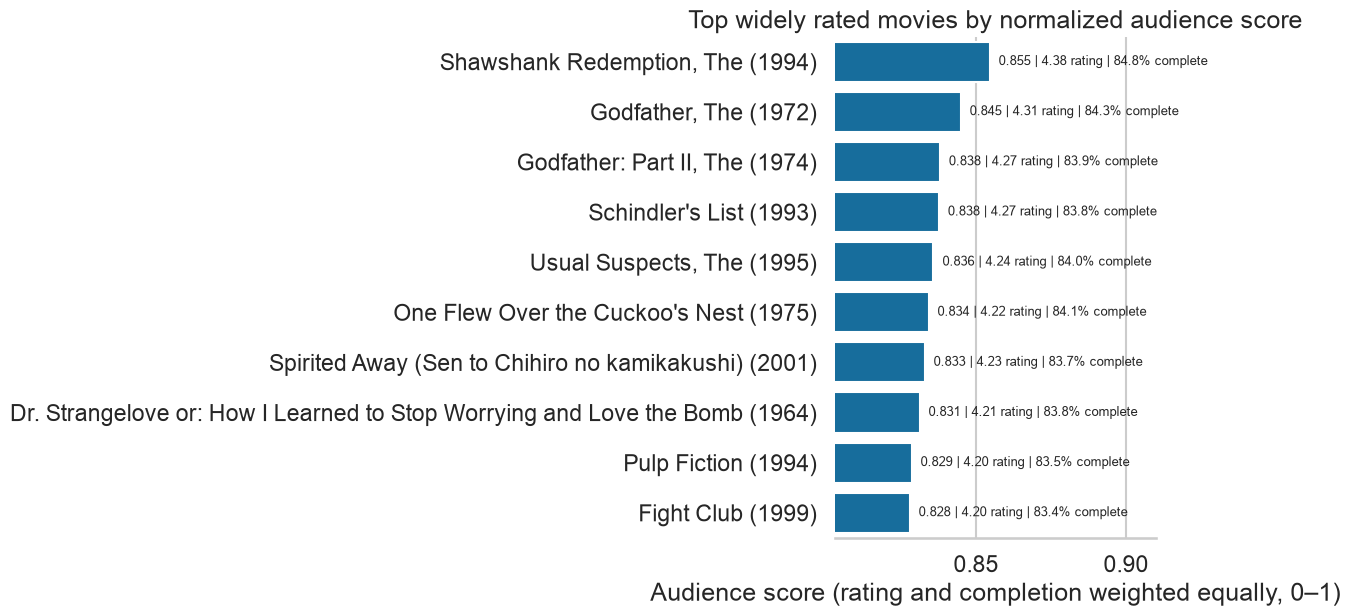

In [8]:
top_movies = pandas_result.head(TOP_N).sort_values("audience_score", ascending=False)
fig, ax = plt.subplots(figsize=(12, 6.5))
sns.barplot(
    data=top_movies,
    x="audience_score",
    y="title",
    order=top_movies["title"],
    color=FRAMEWORK_COLORS["Pandas"],
    ax=ax,
)
ax.set(
    title="Top widely rated movies by normalized audience score",
    xlabel="Audience score (rating and completion weighted equally, 0–1)",
    ylabel="",
)
ax.set_xlim(max(0, top_movies.audience_score.min() - 0.025), 0.91)
for bar, (_, row) in zip(ax.patches, top_movies.iterrows()):
    ax.text(
        row.audience_score + 0.003,
        bar.get_y() + bar.get_height() / 2,
        f"{row.audience_score:.3f} | {row.average_rating:.2f} rating | {row.average_completion_pct:.1f}% complete",
        va="center",
        fontsize=9,
    )
sns.despine(left=True)
plt.tight_layout()
plt.show()

## 3. Keep the workload fixed and switch to Polars

**Guiding question:** What changes when the same local query runs through a parallel native engine?

The analytical steps remain unchanged: read, group, aggregate, filter, join, sort, and materialize. What changes is the execution layer. Polars represents column work as expressions and performs it in a native engine designed to use multiple CPU cores efficiently.

```text
Python expressions → parallel native engine → materialized result
```

This section uses the standard eager-facing Polars API so the main lesson stays focused on engine architecture, not API modes. Predict whether less Python overhead and more parallel work will matter at 1M rows, then compare the result and end-to-end runtime.

In [9]:
polars_start = time.perf_counter()
pl_ratings = pl.read_parquet(RATINGS_PATH, columns=RATING_COLUMNS)
pl_movies = pl.read_parquet(MOVIES_PATH, columns=["movieId", "title"])
polars_result = (
    pl_ratings.group_by("movieId")
    .agg(
        pl.col("rating").mean().alias("average_rating"),
        pl.len().alias("rating_count"),
        pl.col("completion_pct").mean().alias("average_completion_pct"),
        pl.col("watch_minutes").mean().alias("average_watch_minutes"),
        pl.col("helpful_votes").sum().alias("total_helpful_votes"),
        pl.col("rewatch_count").mean().alias("average_rewatch_count"),
    )
    .filter(pl.col("rating_count") >= MIN_RATINGS)
    .join(pl_movies, on="movieId")
    .with_columns(
        (
            (
                (pl.col("average_rating") - RATING_MIN) / (RATING_MAX - RATING_MIN)
                + (pl.col("average_completion_pct") - COMPLETION_MIN)
                / (COMPLETION_MAX - COMPLETION_MIN)
            )
            / 2
        ).alias("audience_score")
    )
    .sort(["audience_score", "rating_count", "movieId"], descending=[True, True, False])
)
polars_runtime = time.perf_counter() - polars_start

## 4. Turn the same query into partitioned PySpark work

**Guiding question:** How does PySpark transform a dataframe request into tasks, and what fixed costs does that introduce?

PySpark first describes **what** result is required. Spark then chooses **how** to produce it:

```text
Python API → logical plan → Catalyst optimization → physical stages → executor tasks
```

The **driver** plans and coordinates the job. **Executors** process partitions, which are chunks of data that can be handled independently. In this demo, driver and executor work stay on one laptop; in production, the same task model can extend across machines.

Before running the cell, make a prediction: at only 1M rows, will partitioned execution save more time than JVM startup, planning, scheduling, and coordination consume?

Interpret the result through the measured boundary: Spark starts or connects to the JVM, optimizes a plan, schedules partition tasks, executes shuffles and joins, and collects the small result. At 1M rows these fixed costs can dominate. Conceptually, read the work as **scan → partial aggregate → shuffle → final aggregate → join → sort**; use `spark_result.explain("formatted")` when the physical plan itself is the teaching objective.

In [10]:
spark_result = spark_result_pd = None
spark_runtime = spark = None
try:
    from pyspark.sql import SparkSession, functions as F

    spark_start = (
        time.perf_counter()
    )  # Cold, end-to-end: startup, reads, query, and collection.
    spark = (
        SparkSession.builder.master("local[*]")
        .appName("MovieLens TA demo")
        .config("spark.ui.enabled", "false")
        .config("spark.sql.shuffle.partitions", "8")
        .getOrCreate()
    )
    spark.sparkContext.setLogLevel("ERROR")
    sr = spark.read.parquet(str(RATINGS_PATH)).select(*RATING_COLUMNS)
    sm = spark.read.parquet(str(MOVIES_PATH)).select("movieId", "title")
    spark_result = (
        sr.groupBy("movieId")
        .agg(
            F.avg("rating").alias("average_rating"),
            F.count("*").alias("rating_count"),
            F.avg("completion_pct").alias("average_completion_pct"),
            F.avg("watch_minutes").alias("average_watch_minutes"),
            F.sum("helpful_votes").alias("total_helpful_votes"),
            F.avg("rewatch_count").alias("average_rewatch_count"),
        )
        .filter(F.col("rating_count") >= MIN_RATINGS)
        .join(sm, "movieId")
        .withColumn(
            "audience_score",
            (
                (F.col("average_rating") - RATING_MIN) / (RATING_MAX - RATING_MIN)
                + (F.col("average_completion_pct") - COMPLETION_MIN)
                / (COMPLETION_MAX - COMPLETION_MIN)
            )
            / 2,
        )
        .orderBy(F.desc("audience_score"), F.desc("rating_count"), F.asc("movieId"))
    )
    spark_result_pd = spark_result.toPandas()
    spark_runtime = time.perf_counter() - spark_start
except Exception as exc:
    spark_result = spark_result_pd = None
    print(f"Spark skipped: {type(exc).__name__}: {exc}")

## 5. Verify computed values before comparing speed

**Guiding question:** What must agree before runtime numbers are comparable?

A faster result is irrelevant if a join, normalization formula, aggregation, or sort direction changed the semantics. The next cell aligns rows by `movieId` and compares all six summaries plus `audience_score`, allowing small floating-point differences and ignoring dtype differences.

Be precise about the evidence: these assertions verify the ranked IDs and numeric summaries, but they do not independently validate title text. Once the wider computed result agrees, we can compare runtimes using the same measurement boundary.

In [11]:
COMPARISON_COLUMNS = [
    "movieId",
    "average_rating",
    "rating_count",
    "average_completion_pct",
    "average_watch_minutes",
    "total_helpful_votes",
    "average_rewatch_count",
    "audience_score",
]


def comparable(frame):
    return frame[COMPARISON_COLUMNS].sort_values("movieId").reset_index(drop=True)


pd.testing.assert_frame_equal(
    comparable(pandas_result),
    comparable(polars_result.to_pandas()),
    check_dtype=False,
    atol=1e-6,
    rtol=1e-6,
)
print("✓ Pandas matches Polars")
if spark_result_pd is not None:
    pd.testing.assert_frame_equal(
        comparable(pandas_result),
        comparable(spark_result_pd),
        check_dtype=False,
        atol=1e-6,
        rtol=1e-6,
    )
    print("✓ PySpark matches")

✓ Pandas matches Polars
✓ PySpark matches


### Separate live observations from prepared benchmark evidence

**Guiding question:** What does the recorded scaling pattern show—and what can it not prove?

The engine cells collect one-shot live timings for classroom discussion, but a single run is too noisy to publish as a ranking. The figures below use prepared median measurements from three end-to-end runs at each tested size. Both boundaries are **read → group → aggregate → filter → join → sort → materialize**.

Read the figures in two passes:

1. **Local crossover:** compare Pandas with Polars Eager and Polars Lazy through 1M rows. Polars Lazy is included as prepared benchmark evidence, not as a fourth live implementation.
2. **Scaling:** compare slopes only where engines share an input size. Lines stop where a run was not completed—Pandas after 100M, Polars Eager after 350M, and Polars Lazy and local PySpark after 500M.

The 350M and 500M inputs repeat the enriched source into exact-size Parquet partitions; they stress volume and architecture but do not represent independent user events. These results describe this machine and protocol, not a universal winner or proof of multi-machine Spark scaling.

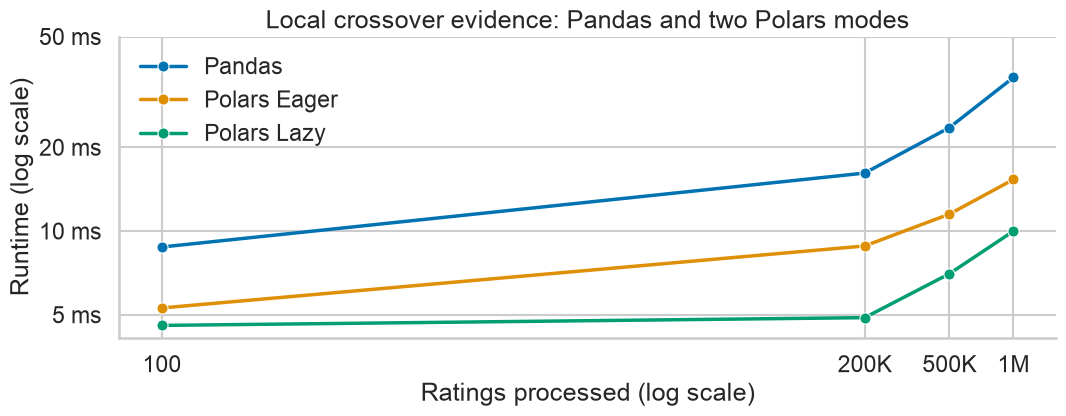

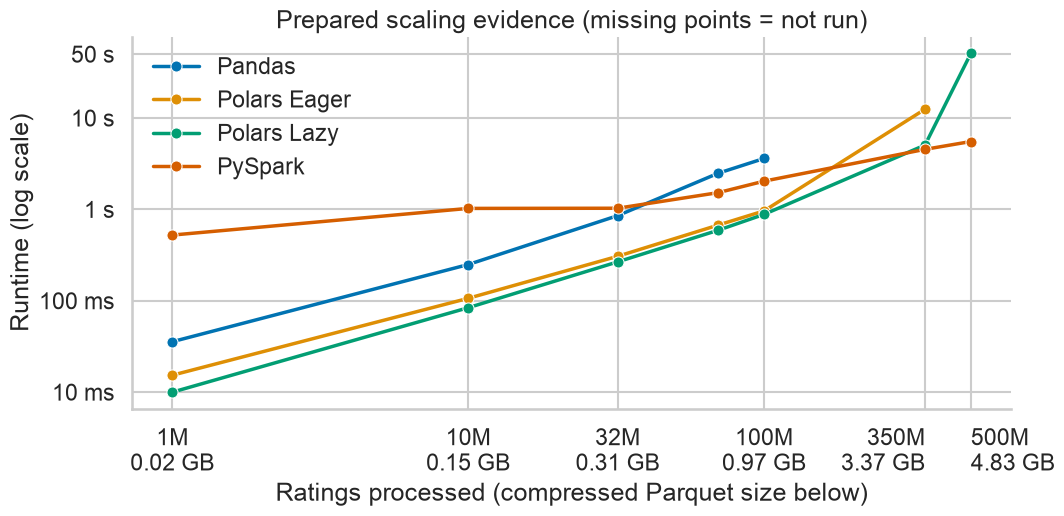

In [12]:
prepared = pd.read_csv(ROOT / "results/benchmark_results_simple.csv")

# Keep the live measurements available for discussion without publishing a one-shot ranking.
live = pd.DataFrame(
    [
        {"framework": framework, "rows": LIVE_ROWS, "runtime_seconds": runtime}
        for framework, runtime in {
            "Pandas": pandas_runtime,
            "Polars Eager": polars_runtime,
            "PySpark": spark_runtime,
        }.items()
        if runtime is not None
    ]
)

from matplotlib.ticker import FuncFormatter, NullFormatter

framework_order = ["Pandas", "Polars Eager", "Polars Lazy", "PySpark"]
polars_modes = ["Polars Eager", "Polars Lazy"]
runtime_formatter = FuncFormatter(
    lambda value, _: f"{value * 1_000:g} ms" if value < 1 else f"{value:g} s"
)


def format_runtime_axis(ax, ticks):
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_yticks(ticks)
    ax.yaxis.set_major_formatter(runtime_formatter)
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.legend(title="", frameon=False)
    sns.despine(ax=ax)


small_local = prepared[
    prepared["framework"].isin(["Pandas", *polars_modes])
    & (prepared["rows"] <= 1_000_000)
]
fig, ax = plt.subplots(figsize=(11, 4.5))
sns.lineplot(
    data=small_local,
    x="rows",
    y="runtime_seconds",
    hue="framework",
    hue_order=["Pandas", *polars_modes],
    marker="o",
    palette=FRAMEWORK_COLORS,
    linewidth=2.5,
    markersize=8,
    ax=ax,
)
format_runtime_axis(ax, ticks=[0.005, 0.01, 0.02, 0.05])
ax.set(
    title="Local crossover evidence: Pandas and two Polars modes",
    xlabel="Ratings processed (log scale)",
    ylabel="Runtime (log scale)",
)
ax.set_xticks([100, 200_000, 500_000, 1_000_000], labels=["100", "200K", "500K", "1M"])
plt.tight_layout()
plt.show()

scale_ticks = [
    1_000_000,
    10_000_000,
    32_000_204,
    100_000_000,
    350_000_000,
    500_000_000,
]
scale_names = ["1M", "10M", "32M", "100M", "350M", "500M"]
scale_paths = [
    ROOT / "data/parquet/ratings_1m.parquet",
    ROOT / "data/parquet/ratings_10m.parquet",
    ROOT / "data/parquet/ratings_32m.parquet",
    ROOT / "data/synthetic/ratings_100m.parquet",
    ROOT / "data/synthetic/ratings_350m.parquet",
    ROOT / "data/synthetic/ratings_500m.parquet",
]


def parquet_size_gb(path):
    files = [path] if path.is_file() else list(path.glob("*.parquet"))
    return sum(file.stat().st_size for file in files) / 1_000_000_000 if files else None


scale_labels = []
for name, path in zip(scale_names, scale_paths):
    size_gb = parquet_size_gb(path)
    size_label = f"{size_gb:.2f} GB" if size_gb is not None else "not local"
    scale_labels.append(f"{name}\n{size_label}")

scaled = prepared[prepared["rows"] >= 1_000_000]
fig, ax = plt.subplots(figsize=(11, 5.5))
sns.lineplot(
    data=scaled,
    x="rows",
    y="runtime_seconds",
    hue="framework",
    hue_order=framework_order,
    marker="o",
    palette=FRAMEWORK_COLORS,
    linewidth=2.5,
    markersize=8,
    ax=ax,
)
format_runtime_axis(ax, ticks=[0.01, 0.1, 1, 10, 50])
ax.set(
    title="Prepared scaling evidence (missing points = not run)",
    xlabel="Ratings processed (compressed Parquet size below)",
    ylabel="Runtime (log scale)",
)
ax.set_xticks(scale_ticks, labels=scale_labels)
tick_labels = ax.get_xticklabels()
tick_labels[-2].set_horizontalalignment("right")
tick_labels[-1].set_horizontalalignment("left")
plt.tight_layout()
plt.show()

## 6. Connect the timings to the demonstrated execution models

**Guiding question:** Where does work run, when is it triggered, and how is it organized in each pipeline?

The API is only the instruction surface; the demonstrated mode determines how work is organized:

- **Pandas:** the standard operations shown here execute eagerly on one machine; native kernels do much of the work, while parallelism varies by operation and dependency.
- **Polars Eager:** expressions execute through a parallel native engine as each eager result is requested.
- **Polars Lazy:** expressions build an optimizable plan, and `collect()` triggers execution on one machine.
- **PySpark:** transformations build a logical plan, and an action schedules partition tasks locally here or across executors in a cluster.

Do not reduce these models to “slow” and “fast.” Each trades simplicity, planning, parallelism, coordination, and scalability differently. The table summarizes the exact modes used here; the diagram then traces where planning, parallelism, and coordination enter each execution path. Neither is a hard data-size cutoff.

In [13]:
framework_summary = pd.DataFrame(
    [
        [
            "Pandas",
            "As each operation is requested",
            "One machine",
            "Calls local native operations",
        ],
        [
            "Polars Eager",
            "As each result is requested",
            "One machine, parallel",
            "Sends expressions to a native engine",
        ],
        [
            "Polars Lazy",
            "When collect() is called",
            "One machine, planned and parallel",
            "Builds an optimizable expression plan",
        ],
        [
            "PySpark",
            "When an action is called",
            "One or many machines",
            "Builds a logical plan for Spark",
        ],
    ],
    columns=["Framework", "When work runs", "Designed scale", "Role of Python"],
)

display(
    framework_summary.style.hide(axis="index")
    .set_properties(**{"text-align": "left"})
    .set_table_styles(
        [{"selector": "th", "props": [("text-align", "left"), ("font-weight", "bold")]}]
    )
)

Framework,When work runs,Designed scale,Role of Python
Pandas,As each operation is requested,One machine,Calls local native operations
Polars Eager,As each result is requested,"One machine, parallel",Sends expressions to a native engine
Polars Lazy,When collect() is called,"One machine, planned and parallel",Builds an optimizable expression plan
PySpark,When an action is called,One or many machines,Builds a logical plan for Spark


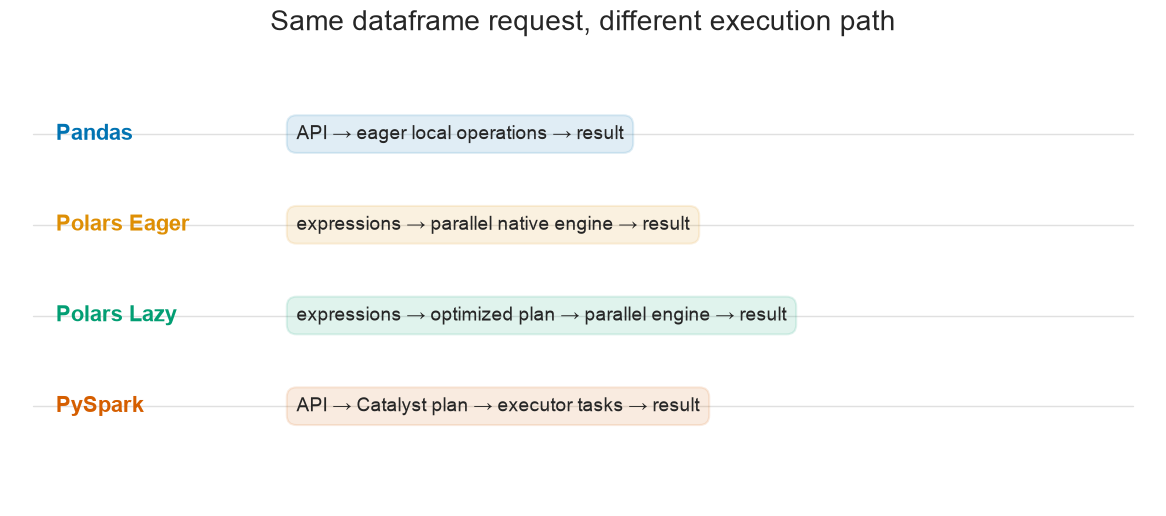

In [14]:
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.axis("off")
paths = [
    ("Pandas", "API → eager local operations → result", "Pandas"),
    ("Polars Eager", "expressions → parallel native engine → result", "Polars Eager"),
    (
        "Polars Lazy",
        "expressions → optimized plan → parallel engine → result",
        "Polars Lazy",
    ),
    ("PySpark", "API → Catalyst plan → executor tasks → result", "PySpark"),
]
for y, (framework, path, color_key) in zip([0.82, 0.62, 0.42, 0.22], paths):
    color = FRAMEWORK_COLORS[color_key]
    ax.axhline(y, xmin=0.02, xmax=0.98, color="0.88", linewidth=1, zorder=0)
    ax.text(0.04, y, framework, fontsize=16, weight="bold", color=color, va="center")
    ax.text(
        0.25,
        y,
        path,
        fontsize=14,
        va="center",
        bbox=dict(
            boxstyle="round,pad=.5", facecolor=color, alpha=0.12, edgecolor=color
        ),
    )
ax.set_title("Same dataframe request, different execution path", fontsize=20, pad=16)
plt.tight_layout()
plt.show()

## 7. Choose from constraints—not from the benchmark winner

**Guiding question:** What additional facts do we need before selecting an engine for each workload?

Pause before revealing the guide. For each scenario, identify the missing constraints that could change your recommendation:

1. Interactive exploration of a 5 GB file by a team with an established Pandas workflow.
2. A repeated 100 GB analytical pipeline on one strong machine.
3. A multi-terabyte scheduled job that must scale beyond one machine.

<details>
<summary><strong>Reveal and discuss the conditional guide</strong></summary>

- **Pandas** may fit scenario 1 if the working set fits memory and ecosystem compatibility matters most.
- **Polars Lazy** is a strong candidate for scenario 2 if its planned or streaming execution keeps memory bounded and supports the required operations.
- **PySpark** is a strong candidate for scenario 3 if cluster infrastructure, distributed execution, and fault recovery justify its coordination cost.

These are starting hypotheses, not automatic answers. Ask about memory, input format, operation shape, concurrency, latency targets, deployment, team skills, and downstream integrations before deciding.

</details>

Speed is only one input. Reliability, maintainability, ecosystem fit, and operational cost can outweigh a benchmark result.

### Close the loop

- **Trust the analysis first:** define row meaning, validate the data, and normalize unlike measures.
- **Compare equivalent work:** hold inputs and materialization boundaries constant, then verify results before timing.
- **Choose from constraints:** explain where, when, and how work runs; include memory, scale, deployment, ecosystem, and team experience.

Choose the execution model that fits the workload you actually have—not a universal benchmark winner.

In [15]:
# Release the local Spark session after the demo.
if spark is not None:
    spark.stop()